# EV Car Prices

This assignment focuses on car prices. The data ('car_prices.xlsx') is a pre-processed version of original data scraped from bilbasen.dk by previous MAL1 students. The dataset contains 16 columns:

- **Price (DKK)**: The current listed price of the vehicle in Danish Kroner.
- **Model Year**: The manufacturing year of the vehicle.
- **Mileage (km)**: The total kilometres driven by the vehicle (odometer reading).
- **Electric Range (km)**: The estimated maximum driving range on a full charge.
- **Battery Capacity (kWh)**: The total capacity of the vehicle's battery in kilowatt-hours.
- **Energy Consumption (Wh/km)**: The vehicle's energy consumption in watt-hours per kilometre.
- **Annual Road Tax (DKK)**: The annual road tax cost in Danish Kroner.
- **Horsepower (bhp)**: The vehicle's horsepower (brake horsepower).
- **0-100 km/h (s)**: The time (in seconds) for the car to accelerate from 0 to 100 km/h.
- **Top Speed (km/h)**: The maximum speed the vehicle can achieve.
- **Towing Capacity (kg)**: The maximum weight the vehicle can tow.
- **Original Price (DKK)**: The price of the vehicle when first sold as new.
- **Number of Doors**: The total number of doors on the vehicle.
- **Rear-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for rear-wheel drive.
- **All-Wheel Drive (AWD)**: A binary indicator (1 = Yes, 0 = No) for all-wheel drive.
- **Front-Wheel Drive**: A binary indicator (1 = Yes, 0 = No) for front-wheel drive.

The first one, **Price**, is the response variable.

The **objective** of this assignment is:
1. Understand how linear algebra is used in Machine Learning, specifically for correlations and regression
2. Learn how to perform multiple linear regression, ridge regression, lasso regression and elastic net
3. Learn how to assess regression models

Please solve the tasks using this notebook as you template, i.e. insert code blocks and markdown block to this notebook and hand it in. Please use 42 as your random seed.


## Import data
 - Import the dataset 
 - Split the data in a training set and test set - make sure you extract the response variable
 - Remember to use the data appropriately; in the tasks below, we do not explicitly state when to use train and test - but in order to compare the models, you must use the same dataset for training and testing in all models.
 - Output: When you are done with this, you should have the following sets: `X` (the original dataset), `X_train`, `X_train`, `X_test`, `y_train`, `y_test`

In [3]:
# Code block for important and creating data sets. Add more code blocks if needed.

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from IPython.display import display 

# Set random seed
np.random.seed(42)

# Load dataset
df = pd.read_excel("car_prices.xlsx")

# We drop the "All-Wheel Drive (AWD)" category pr. Ole's heads up on itsLearning:
# Ole Ildsgaard Hougaard (26/02-2025):
# Vi er kommet til at lægge en fælde ind i aflevering 2: Når man har en one-hot encoded feature,
# kan man ikke løse lineær regression efter den angivne matrix-metode. For at løse den korrekt
# skal I droppe en af søjlerne "Rear-Wheel Drive", "All-Wheel Drive" eller "Front-Wheel Drive".
df = df.drop(columns=["All-Wheel Drive (AWD)"])

# Define feature matrix (X) and target vector (y)
y = df["Price (DKK)"].values
X = df.drop(columns=["Price (DKK)"]).values

# Extract feature names and add Intercept
feature_names = ["Intercept"] + list(df.drop(columns=["Price (DKK)"]).columns)

# Add a column of ones to X for the intercept term
X = np.c_[np.ones(X.shape[0]), X] 

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize X (excluding the first column which is the intercept)
scaler = StandardScaler()
X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])  # Scale only feature columns
X_test[:, 1:] = scaler.transform(X_test[:, 1:])  # Use the same scaler for test set


## Part 1: Linear Algebra
In this assignment, you have to solve all problems using linear algebra concepts. You are free to use SymPy or NumPy - though NumPy is **significantly** more efficient computationally than SymPy since NumPy is optimized for numerical computations with floating-point arithmetic. Since linear regression is purely numerical, NumPy is the better choice.


### Task 1: Regression



Linear regression finds the best-fitting line (or hyperplane) by solving for the **coefficient vector** $\mathbf{B}$ that minimizes the squared error:

$$
\mathbf{B} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

where:
- $\mathbf{X}$ is the **design matrix**, including a column of ones for the intercept.
- $\mathbf{y}$ is the **response variable** (target values).
- $\mathbf{B}$ contains the **regression coefficients**.

**Explanation of Each Step**
1. **Construct the matrix $X$**:
   - Each **row** represents a data point.
   - Each **column** represents a feature.
   - The **first column is all ones** to account for the **intercept**.

2. **Solve for $\mathbf{B}$ using the normal equation**:
   - Compute $X^T X$ (feature correlation).
   - Compute $X^T y$ (cross-product with the target variable).
   - Compute the **inverse of $X^T X$** and multiply by $X^T y$ to get $\mathbf{B}$.

3. **Interpret the results**:
   - The **first value** in $\mathbf{B}$ is the **intercept**.
   - The remaining values are the **coefficients for each feature**.



In [4]:
# Compute the normal equation: B = (X^T X)^(-1) X^T y
# This is the closed-form solution for linear regression.
# It finds the optimal coefficients (B) by minimizing the sum of squared residuals.
# The pseudoinverse (pinv) is used instead of the regular inverse to handle cases where (X^T X) is singular.
B = np.linalg.pinv(X_train.T @ X_train) @ X_train.T @ y_train

# Pair feature names with their corresponding coefficients
# This step creates a dictionary where each feature name is mapped to its corresponding coefficient.
# The coefficient represents the feature's contribution to the target variable.
coefficients = dict(zip(feature_names, B))

# Create a DataFrame to display the regression results
# This DataFrame provides a structured view of the computed coefficients for better interpretation.
coefficients_df = pd.DataFrame(coefficients.items(), columns=["Feature", "Coefficient"])

# Display the regression coefficients using pandas
# The display function ensures a clean and readable table format for analysis.
display(coefficients_df)

,Feature,Coefficient
0,Intercept,320080.058635
1,Model Year,25007.054556
2,Mileage (km),-15365.038887
3,Electric Range (km),10511.250034
4,Battery Capacity (kWh),802.032675
5,Energy Consumption (Wh/km),2703.743666
6,Annual Road Tax (DKK),-9338.347940
7,Horsepower (bhp),2677.899245
8,0-100 km/h (s),11466.392278
9,Top Speed (km/h),3808.271305


Task 2: Evaluating the Model

Once we have the regression coefficients $\mathbf{B}$, we can evaluate how well the model fits the data using two key metrics:

1. **Mean Squared Error (MSE)** – Measures the average squared difference between the predicted and actual values:
   $$
   MSE = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2
   $$
   - Lower MSE means better fit.

2. **$R^2$ (Coefficient of Determination)** – Measures how much of the variance in $y$ is explained by $X$:
   $$
   R^2 = 1 - \frac{\sum (y - \hat{y})^2}{\sum (y - \bar{y})^2}
   $$
   - $R^2$ ranges from **0 to 1**, where **1** indicates a perfect fit and **0** means the model explains no variance.


**Explanation of Each Step**
1. **Compute Predictions**:  
   $$ \hat{y} = X B $$
   This gives the model’s predicted values.

2. **Compute MSE**:  
   - We square the residuals $ (y - \hat{y})^2 $ and take the mean.

3. **Compute $R^2$**:
   - **Total sum of squares** $ SS_{total} $ measures the total variance in $ y $.
   - **Residual sum of squares** $ SS_{residual} $ measures the variance left unexplained by the model.
   - $ R^2 $ tells us what fraction of variance is explained.

**Interpreting the Results**
- **MSE**: Lower values indicate a better fit.
- **$R^2$ Score**:
  - **$R^2 = 1$** → Perfect fit (all points on the regression line).
  - **$R^2 = 0$** → Model is no better than predicting the mean of $ y $.
  - **$R^2 < 0$** → Model performs worse than a simple average.

Implement the above steps using linear algebra so that you both create a regression model and calculate the MSE and $R^2$. Note, here you need to use `X_train`, `X_test`, `y_train` and `y_test` appropriately!


In [5]:
# Use this for Task 2. Add more code blocks if needed.

# Compute predictions on the test set
# Using the previously computed coefficients (B), we predict the target values (y_pred) for the test set.
# This is done by performing matrix multiplication between the feature matrix (X_test) and the coefficient vector (B).
y_pred = X_test @ B

# Compute Mean Squared Error (MSE)
# MSE measures the average squared difference between actual (y_test) and predicted (y_pred) values.
# It quantifies the model's prediction error, where a lower MSE indicates better performance.
mse = np.mean((y_test - y_pred) ** 2)

# Compute R² (Coefficient of Determination)
# R² measures how well the independent variables explain the variance in the dependent variable.
# It ranges from 0 to 1, where 1 indicates perfect prediction and 0 means the model explains no variance.
ss_total = np.sum((y_test - np.mean(y_test)) ** 2)  # Total sum of squares (SStotal) - measures total variation in y_test
ss_residual = np.sum((y_test - y_pred) ** 2)  # Residual sum of squares (SSresidual) - measures unexplained variation
r2_score = 1 - (ss_residual / ss_total)  # R² formula: proportion of variance explained by the model

# Display results
# Creating a DataFrame to present the computed evaluation metrics in a structured format.
# This helps in assessing the model’s performance based on MSE and R² Score.
evaluation_metrics = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "R² Score"],
    "Value": [mse, r2_score]
})

# Display the evaluation metrics in a table format for easy interpretation.
display(evaluation_metrics)

,Metric,Value
0,Mean Squared Error (MSE),2.774487e+09
1,R² Score,8.644264e-01


# Part 2: Using Library Functions

### Task 4: Correlation and OLS
For this task you must do the following
 - Using library functions, build the following models:
   - Correlation matrix where the correlations are printed in the matrix and a heat map is overlaid
   - Ordinary least squares
   - Performance metrics: MSE, RMSE, $R^2$
   - Comment on the real world meaning of RMSE and $R^2$


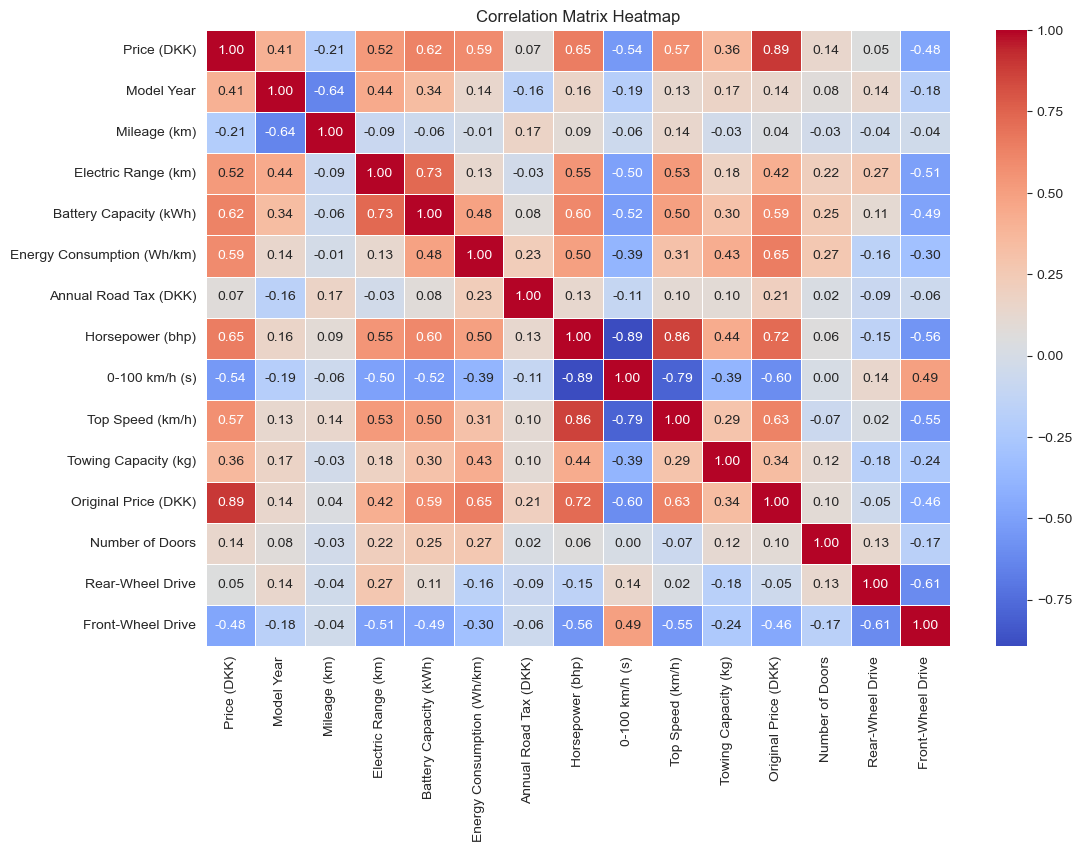

,Metric,Value
0,Mean Squared Error (MSE),2.272994e+09
1,Root Mean Squared Error (RMSE),4.767593e+04
2,R² Score,8.958552e-01


In [6]:
# Use this for Task 4. Add more code blocks if needed.
import statsmodels.api as sm  # Importing statsmodels for OLS regression
import seaborn as sns  # Importing seaborn for visualization
import matplotlib.pyplot as plt  # Importing matplotlib for plotting

# Task 4: Correlation Matrix
# The correlation matrix measures the linear relationships between variables in the dataset.
# It helps identify multicollinearity, which can affect regression model performance.
plt.figure(figsize=(12, 8))  # Set figure size for better readability
correlation_matrix = df.corr()  # Compute the Pearson correlation matrix for all numerical features

# Create a heatmap with correlation values displayed
# - `annot=True` displays numerical correlation values within each cell
# - `fmt=".2f"` ensures values are rounded to two decimal places
# - `cmap="coolwarm"` uses a color gradient from cool (negative correlation) to warm (positive correlation)
# - `linewidths=0.5` adds gridlines for better separation of values
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Matrix Heatmap")  # Set title for the plot
plt.show()  # Display the heatmap

# Add intercept manually for OLS (Ordinary Least Squares) regression
# The intercept allows the regression line to adjust instead of passing through the origin.
X_ols = sm.add_constant(X)

# Fit the OLS model
# OLS (Ordinary Least Squares) is a fundamental linear regression method that minimizes the sum of squared residuals.
# This step fits the regression model to the data and estimates the coefficients.
ols_model = sm.OLS(y, X_ols).fit()

# Display OLS summary
# The summary provides statistical details about the model, including coefficients, p-values, and R².
ols_summary = ols_model.summary()
ols_summary  # Display the regression summary in textual format

# Compute predictions using the OLS model
# This generates predicted values using the fitted OLS regression model.
y_pred_ols = ols_model.predict(X_ols)

# Compute MSE (Mean Squared Error)
# MSE measures the average squared difference between actual and predicted values.
mse_ols = np.mean((y - y_pred_ols) ** 2)

# Compute RMSE (Root Mean Squared Error)
# RMSE is the square root of MSE, providing an interpretable error metric in the same unit as the dependent variable.
rmse_ols = np.sqrt(mse_ols)

# Compute R² (Coefficient of Determination) from the OLS model
# R² represents the proportion of variance in the target variable explained by the model.
# A higher R² (closer to 1) indicates a better fit.
r2_ols = ols_model.rsquared

# Display performance metrics
# Creating a structured table to summarize model performance
performance_metrics_ols = pd.DataFrame({
    "Metric": ["Mean Squared Error (MSE)", "Root Mean Squared Error (RMSE)", "R² Score"],
    "Value": [mse_ols, rmse_ols, r2_ols]
})

# Display the results using IPython display
# This table makes it easier to compare different models and evaluate performance.
display(performance_metrics_ols)


With a lower MSE(therefore also lower RMSE) in this model compared to the Linear regression model in task 2, we can conclude that OLS is more precise with this dataset. A RMSE of 47.676DKK is a deviance of 10-15% when looking at cars priced 300.000-500.000DKK, which is okay for a general prediction model. If a precise prediction is the goal, the deviance is too high.
R2 Score of 0,895 is higher than the task 2 model, which means that a higher percentage of variance is explained in the OLS model, and that the model effectively captures the relationship between features and price.

### Task 5: Ridge, Lasso and Elastic Net
In order for Ridge and Lasso (and Elastic net) to have an effect, you must use scaled data to build the models, since regularization depends on coefficient magnitude, and if using non-scaled data the penalty will affect them unequally. Feel free to use this code to scale the data:

```python
# Standardize X
scaler_X = StandardScaler()
X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled = scaler_X.transform(X_test)

# Standardize y
scaler_y = StandardScaler()
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()
```
For the final task you must do the following
   - Ridge regression (using multiple alphas)
   - Lasso regression (using multiple alphas)
   - Elastic Net (using multiple alphas)
 - Discussion and conclusion:
   - Discuss the MSE and $R^2$ of all 3 models and conclude which model has the best performance - note the MSE will be scaled!
   - Rebuild the OLS model from Task 4, but this time use the scaled data from this task - interpret the meaning of the model's coefficients
   - Use the coefficients of the best ridge and lasso model to print the 5 most important features and compare to the 5 most important features in the OLS with scaled data model. Do the models agree about which features are the most important?

Note: You may get a convergence warning; try increasing the `max_iter` parameter of the model (the default is 1000 - maybe set it to 100000)

In [7]:
# Use this for Task 5. Add more code blocks if needed.
# Import necessary libraries for Ridge, Lasso, and Elastic Net Regression
# These regression techniques help handle multicollinearity and prevent overfitting by applying regularization.
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_squared_error  # To evaluate model performance using MSE

# Step 1: Standardize Data
# Standardization is necessary for regularized regression models to ensure all features contribute equally.
scaler_X = StandardScaler()  # Initialize standard scaler for feature matrix
X_train_scaled = scaler_X.fit_transform(X_train[:, 1:])  # Fit & transform training data (excluding intercept column)
X_test_scaled = scaler_X.transform(X_test[:, 1:])  # Transform test data using the same scaler

scaler_y = StandardScaler()  # Initialize standard scaler for target variable
y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1, 1)).flatten()  # Standardize y_train
y_test_scaled = scaler_y.transform(y_test.reshape(-1, 1)).flatten()  # Standardize y_test

# Step 2: Train Ridge, Lasso, and Elastic Net Models with multiple alpha values
# Alpha controls the strength of regularization; higher alpha values impose stronger penalties.
alphas = [0.01, 0.1, 1, 10, 100]  # Different levels of regularization

# Lists to store results for each model type
ridge_results, lasso_results, elastic_net_results = [], [], []

# Iterate over different alpha values and train models
for alpha in alphas:
    # Ridge Regression (L2 regularization)
    # Penalizes large coefficients by adding the squared sum of coefficients to the loss function.
    ridge = Ridge(alpha=alpha, max_iter=100000)  # Set alpha and maximum iterations
    ridge.fit(X_train_scaled, y_train_scaled)  # Train model
    ridge_pred = ridge.predict(X_test_scaled)  # Predict on test data
    ridge_mse = mean_squared_error(y_test_scaled, ridge_pred)  # Compute MSE
    ridge_r2 = ridge.score(X_test_scaled, y_test_scaled)  # Compute R² score
    ridge_results.append([alpha, ridge_mse, np.sqrt(ridge_mse), ridge_r2])  # Store results

    # Lasso Regression (L1 regularization)
    # Encourages sparsity by forcing some coefficients to be exactly zero, performing feature selection.
    lasso = Lasso(alpha=alpha, max_iter=100000)  # Set alpha and maximum iterations
    lasso.fit(X_train_scaled, y_train_scaled)  # Train model
    lasso_pred = lasso.predict(X_test_scaled)  # Predict on test data
    lasso_mse = mean_squared_error(y_test_scaled, lasso_pred)  # Compute MSE
    lasso_r2 = lasso.score(X_test_scaled, y_test_scaled)  # Compute R² score
    lasso_results.append([alpha, lasso_mse, np.sqrt(lasso_mse), lasso_r2])  # Store results

    # Elastic Net Regression (Combination of L1 and L2 regularization)
    # Combines Lasso and Ridge to balance sparsity and coefficient shrinkage.
    elastic_net = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=100000)  # Set alpha, l1_ratio, and max iterations
    elastic_net.fit(X_train_scaled, y_train_scaled)  # Train model
    elastic_net_pred = elastic_net.predict(X_test_scaled)  # Predict on test data
    elastic_net_mse = mean_squared_error(y_test_scaled, elastic_net_pred)  # Compute MSE
    elastic_net_r2 = elastic_net.score(X_test_scaled, y_test_scaled)  # Compute R² score
    elastic_net_results.append([alpha, elastic_net_mse, np.sqrt(elastic_net_mse), elastic_net_r2])  # Store results

# Convert results to DataFrame for easy interpretation
ridge_df = pd.DataFrame(ridge_results, columns=["Alpha", "MSE", "RMSE", "R²"])
lasso_df = pd.DataFrame(lasso_results, columns=["Alpha", "MSE", "RMSE", "R²"])
elastic_net_df = pd.DataFrame(elastic_net_results, columns=["Alpha", "MSE", "RMSE", "R²"])

# Display results
# These tables show how different levels of regularization affect the model's performance.
display(ridge_df)
display(lasso_df)
display(elastic_net_df)


,Alpha,MSE,RMSE,R²
0,0.01,0.125188,0.353819,0.864426
1,0.10,0.125189,0.353820,0.864425
2,1.00,0.125197,0.353832,0.864416
3,10.00,0.125290,0.353963,0.864316
4,100.00,0.126594,0.355801,0.862903


,Alpha,MSE,RMSE,R²
0,0.01,0.122944,0.350633,0.866857
1,0.10,0.148866,0.385831,0.838784
2,1.00,0.924087,0.961295,-0.000753
3,10.00,0.924087,0.961295,-0.000753
4,100.00,0.924087,0.961295,-0.000753


,Alpha,MSE,RMSE,R²
0,0.01,0.123782,0.351827,0.865949
1,0.10,0.135475,0.368069,0.853286
2,1.00,0.566144,0.752425,0.386887
3,10.00,0.924087,0.961295,-0.000753
4,100.00,0.924087,0.961295,-0.000753


In all 3 models, the lowest alpha gives the best results, where Lasso slightly outperforms the others.

In [8]:
# Rebuild OLS Model using Scaled Data
# Standardization improves numerical stability and ensures fair coefficient comparisons.
# Here, we apply OLS regression to the standardized dataset.

# Add an intercept to the standardized feature matrix for OLS regression
# This allows the model to estimate an intercept term rather than forcing it through the origin.
X_train_scaled_ols = sm.add_constant(X_train_scaled)
X_test_scaled_ols = sm.add_constant(X_test_scaled)

# Fit the OLS model using the standardized training data
# OLS (Ordinary Least Squares) estimates coefficients that minimize the sum of squared residuals.
ols_model_scaled = sm.OLS(y_train_scaled, X_train_scaled_ols).fit()

# Display OLS summary
# The summary includes key statistics such as:
# - Coefficients for each feature
# - p-values (to test significance)
# - R² score (to measure model fit)
# - Standard errors of the coefficients
ols_summary_scaled = ols_model_scaled.summary()
ols_summary_scaled  # Display the regression summary


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.903
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                     3284.
Date:                Sun, 02 Mar 2025   Prob (F-statistic):               0.00
Time:                        16:47:30   Log-Likelihood:                -1269.1
No. Observations:                4980   AIC:                             2568.
Df Residuals:                    4965   BIC:                             2666.
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const       6.158e-17      0.004   1.39e-14      1.000      -0.009       0.009
x1             0.1680      0.007     24.192      0.000       0.154       0.182
x2            -0.1032      0.006    -16.684      0.000      -0.115      -0.091
x3             0.0706      0.008      8.326      0.000       0.054       0.087
x4             0.0054      0.008      0.712      0.477      -0.009       0.020
x5             0.0182      0.007      2.477      0.013       0.004       0.033
x6            -0.0627      0.005    -13.216      0.000      -0.072      -0.053
x7             0.0180      0.017      1.049      0.294      -0.016       0.052
x8             0.0770      0.010      7.565      0.000       0.057       0.097
x9             0.0256      0.010      2.530      0.011       0.006       0.045
x10            0.0475      0.005      8.989      0.000       0.037       0.058
x11            0.8500      0.008    111.748      0.000       0.835       0.865
x12            0.0111      0.005      2.204      0.028       0.001       0.021
x13            0.0409      0.010      4.109      0.000       0.021       0.060
x14            0.0048      0.011      0.442      0.658      -0.017       0.026
==============================================================================
Omnibus:                     1193.714   Durbin-Watson:                   1.937
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            71854.558
Skew:                          -0.070   Prob(JB):                         0.00
Kurtosis:                      21.608   Cond. No.                         10.8
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

The best R2 result yet, which means that 90,3% of variance is explained by the model, which is a strong fit.
The 3 most important coefficients are Original Price, Model year and mileage, where original price is leading by far in importance. This tells us that the more expensive a car was from new, the younger it is, and the shorter its mileage, has the biggest saying on the current price.
The OLS also says the there is a high chance of multicollinearity which means that some features are highly correlated and should be reduced.

In [9]:
# Retrieve the best alpha values for Ridge and Lasso from previous analysis
# We select the alpha that minimizes the Mean Squared Error (MSE) for each model.
# This ensures we are using the optimal regularization strength for Ridge and Lasso.
best_ridge_alpha = ridge_df.loc[ridge_df["MSE"].idxmin(), "Alpha"]
best_lasso_alpha = lasso_df.loc[lasso_df["MSE"].idxmin(), "Alpha"]

# Train Ridge and Lasso with the best alpha values
# Using the optimal alpha values, we retrain Ridge and Lasso models for better performance.
best_ridge_model = Ridge(alpha=best_ridge_alpha, max_iter=100000)
best_ridge_model.fit(X_train_scaled, y_train_scaled)
ridge_coefficients = best_ridge_model.coef_  # Extract learned coefficients

best_lasso_model = Lasso(alpha=best_lasso_alpha, max_iter=100000)
best_lasso_model.fit(X_train_scaled, y_train_scaled)
lasso_coefficients = best_lasso_model.coef_  # Extract learned coefficients

# Extract OLS coefficients from the previously trained scaled OLS model
# Excluding the intercept since we are comparing only feature coefficients.
ols_coefficients = ols_model_scaled.params[1:]  # OLS coefficients (excluding intercept)

# Create DataFrames for easy comparison
# These DataFrames will help in analyzing and comparing feature importance across different models.
ridge_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": ridge_coefficients})
lasso_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": lasso_coefficients})
ols_df = pd.DataFrame({"Feature": feature_names[1:], "Coefficient": ols_coefficients})

# Select top 5 most important features based on absolute values of coefficients
# Features with the highest absolute coefficient values have the most impact on predictions.
ridge_top5 = ridge_df.reindex(ridge_df["Coefficient"].abs().nlargest(5).index)
lasso_top5 = lasso_df.reindex(lasso_df["Coefficient"].abs().nlargest(5).index)
ols_top5 = ols_df.reindex(ols_df["Coefficient"].abs().nlargest(5).index)

# Display the results
# These tables will show the top 5 most influential features in Ridge, Lasso, and OLS models.
display(ridge_top5)
display(lasso_top5)
display(ols_top5)

,Feature,Coefficient
10,Original Price (DKK),0.850034
0,Model Year,0.167977
1,Mileage (km),-0.103211
7,0-100 km/h (s),0.077022
2,Electric Range (km),0.070607


,Feature,Coefficient
10,Original Price (DKK),0.841946
0,Model Year,0.169218
1,Mileage (km),-0.094774
2,Electric Range (km),0.063297
5,Annual Road Tax (DKK),-0.051177


,Feature,Coefficient
10,Original Price (DKK),0.850039
0,Model Year,0.167978
1,Mileage (km),-0.103210
7,0-100 km/h (s),0.077022
2,Electric Range (km),0.070606


Ridge and OLS agree 100% on the 5 most important features, where lasso disagrees on important features #4 and #5. The coefficients on those two features are however very low, so it makes little to no difference for the overall prediction capabilities of the model. It's also important to point out that Lasso provides a simpler model by removing redundant features, which could be why it has other features as #4 and #5 on the most important list.
Overall the models mostly agree on important features, and I think it's safe to say that the 3 most important features are the most defining features, where #1 is significantly more important than the others, as seen by the big jump in coefficient size.